# Rulkov map 0320 workflow

这个 notebook 按照 `twogroup_gram_0313.ipynb` 的顺序组织 Rulkov map 流程，参考 `example_maps_Q` 的数据生成与微观展示逻辑。

- 数据使用两群体 Rulkov map 耆合逻辑
- 观测 library 默认为 `identity + quadratic`
- 主链路包括 `C00/C01/C11 -> K -> Kbar -> SVD -> rank截断 -> CE/EC -> 粗粒化`
- 所有热力图统一使用 `cmap="vlag"`


## 1. 环境与工具

这一步在做什么：

- 定位仓库根目录，避免 notebook 在不同 cwd 下无法 import
- 导入 Rulkov workflow 所需的工具
- 设置绘图风格和输出目录


In [3]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import Ridge

cwd = Path.cwd().resolve()
repo_root = next(path for path in [cwd, *cwd.parents] if (path / 'tools' / 'tools.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

from exp.map.rulkov_map_tools import (
    ObservableConfig,
    RulkovSimulationConfig,
    WorkflowConfig,
    build_observables,
    build_state_matrix_from_population_data,
    channel_scores_from_singular_values,
    compute_entropy,
    compute_residual_covariance,
    fit_data_koopman_operator,
    format_equations,
    generate_two_population_neuron_data,
    get_positive_contributions,
    koopman_ce_total_score_from_kbar,
    liu2025_log_gamma_gis,
    plot_macro_series,
    plot_matrix_heatmap,
    plot_micro_macro_comparison,
    plot_neuron_analysis_combo,
    plot_rectangular_heatmap,
    plot_singular_value_comparison,
    save_workflow_results,
    set_plot_style,
    whiten_operator_matrix,
)

set_plot_style()
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
np.set_printoptions(precision=4, suppress=True)

results_dir = repo_root / 'exp' / 'map' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
print('repo_root =', repo_root)
print('results_dir =', results_dir)
print('font.sans-serif =', plt.rcParams['font.sans-serif'])


repo_root = E:\code\pykoop
results_dir = E:\code\pykoop\exp\map\results
font.sans-serif = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'Arial Unicode MS', 'DejaVu Sans']


## 2. 参数配置

这一步在做什么：

- 将数据生成参数切换到本次实验所需的 `100 + 100` 神经元配置
- 保持 library 为 `identity + quadratic`
- 设置 rank 截断与 CE 闭式接口开关


In [5]:
seed = 103
simulation_config = RulkovSimulationConfig(
    n_a=100,
    n_b=100,
    alpha_a=4.6,
    alpha_b=4.6,
    sigma_a=0.225,
    sigma_b=0.225,
    mu=0.001,
    gamma=0.06,
    epsilon=0.02,
    total_steps=7000,
    burn_in=5000,
    seed=seed,
    x0_a=-1.0,
    x0_b=-1.2,
    y0_a=-3.5,
    y0_b=-3.7,
)
observable_config = ObservableConfig(mode='identity_quadratic', polynomial_degree=2, include_bias=False)
workflow_config = WorkflowConfig(
    simulation=simulation_config,
    observables=observable_config,
    lag_steps=1,
    rank=2,
    alpha=1.0,
    ridge=1e-10,
    eps=1e-10,
    include_closed_form_ce=True,
    results_dir=results_dir,
)
config_df = pd.DataFrame([
    {
        'n_a': simulation_config.n_a,
        'n_b': simulation_config.n_b,
        'alpha_a': simulation_config.alpha_a,
        'alpha_b': simulation_config.alpha_b,
        'sigma_a': simulation_config.sigma_a,
        'sigma_b': simulation_config.sigma_b,
        'mu': simulation_config.mu,
        'gamma': simulation_config.gamma,
        'epsilon': simulation_config.epsilon,
        'T': simulation_config.total_steps,
        'transients': simulation_config.burn_in,
        'seed': simulation_config.seed,
        'x0_a': simulation_config.x0_a,
        'x0_b': simulation_config.x0_b,
        'y0_a': simulation_config.y0_a,
        'y0_b': simulation_config.y0_b,
    }
])
display(config_df)


,n_a,n_b,alpha_a,alpha_b,sigma_a,sigma_b,mu,gamma,epsilon,T,transients,seed,x0_a,x0_b,y0_a,y0_b
0,100,100,4.6,4.6,0.225,0.225,0.001,0.06,0.02,7000,5000,103,-1.0,-1.2,-3.5,-3.7


## 3. 数据生成

这一步在做什么：

- 按照 `example_maps_Q` 风格生成两群体 Rulkov 数据
- 查看参考数据是否存在以及 fallback 来源
- 输出同步指标和基本统计


In [7]:
data = generate_two_population_neuron_data(simulation_config)
summary_df = pd.DataFrame([data['summary']])
display(Markdown(f"- reference available: `{data['reference_info']['available']}`"))
display(Markdown(f"- source note: {data['source_note']}"))
display(summary_df)
print('sync_state =', data['summary']['sync_state'])
print('state_matrix shape =', data['state_matrix'].shape)
print('effective steps =', data['state_matrix'].shape[0])


sync_state = Generalized Synchronization 广义同步(GS)
state_matrix shape = (2000, 400)
effective steps = 2000


- reference available: `True`

- source note: reference data found: exp\discrete_maps\examp_map_Q.ipynb

,seed,R_a,R_b,R_t,R_delta,sync_state
0,103,1.838120e-15,1.791873e-15,1.059189,2.118379,Generalized Synchronization 广义同步(GS)


## 4. 微观数据组合展示

这一步在做什么：

- 参考 `plot_neuron_analysis_combo(simulation_results[i])` 的展示方式
- 同时看平均场轨迹与微观 heatmap


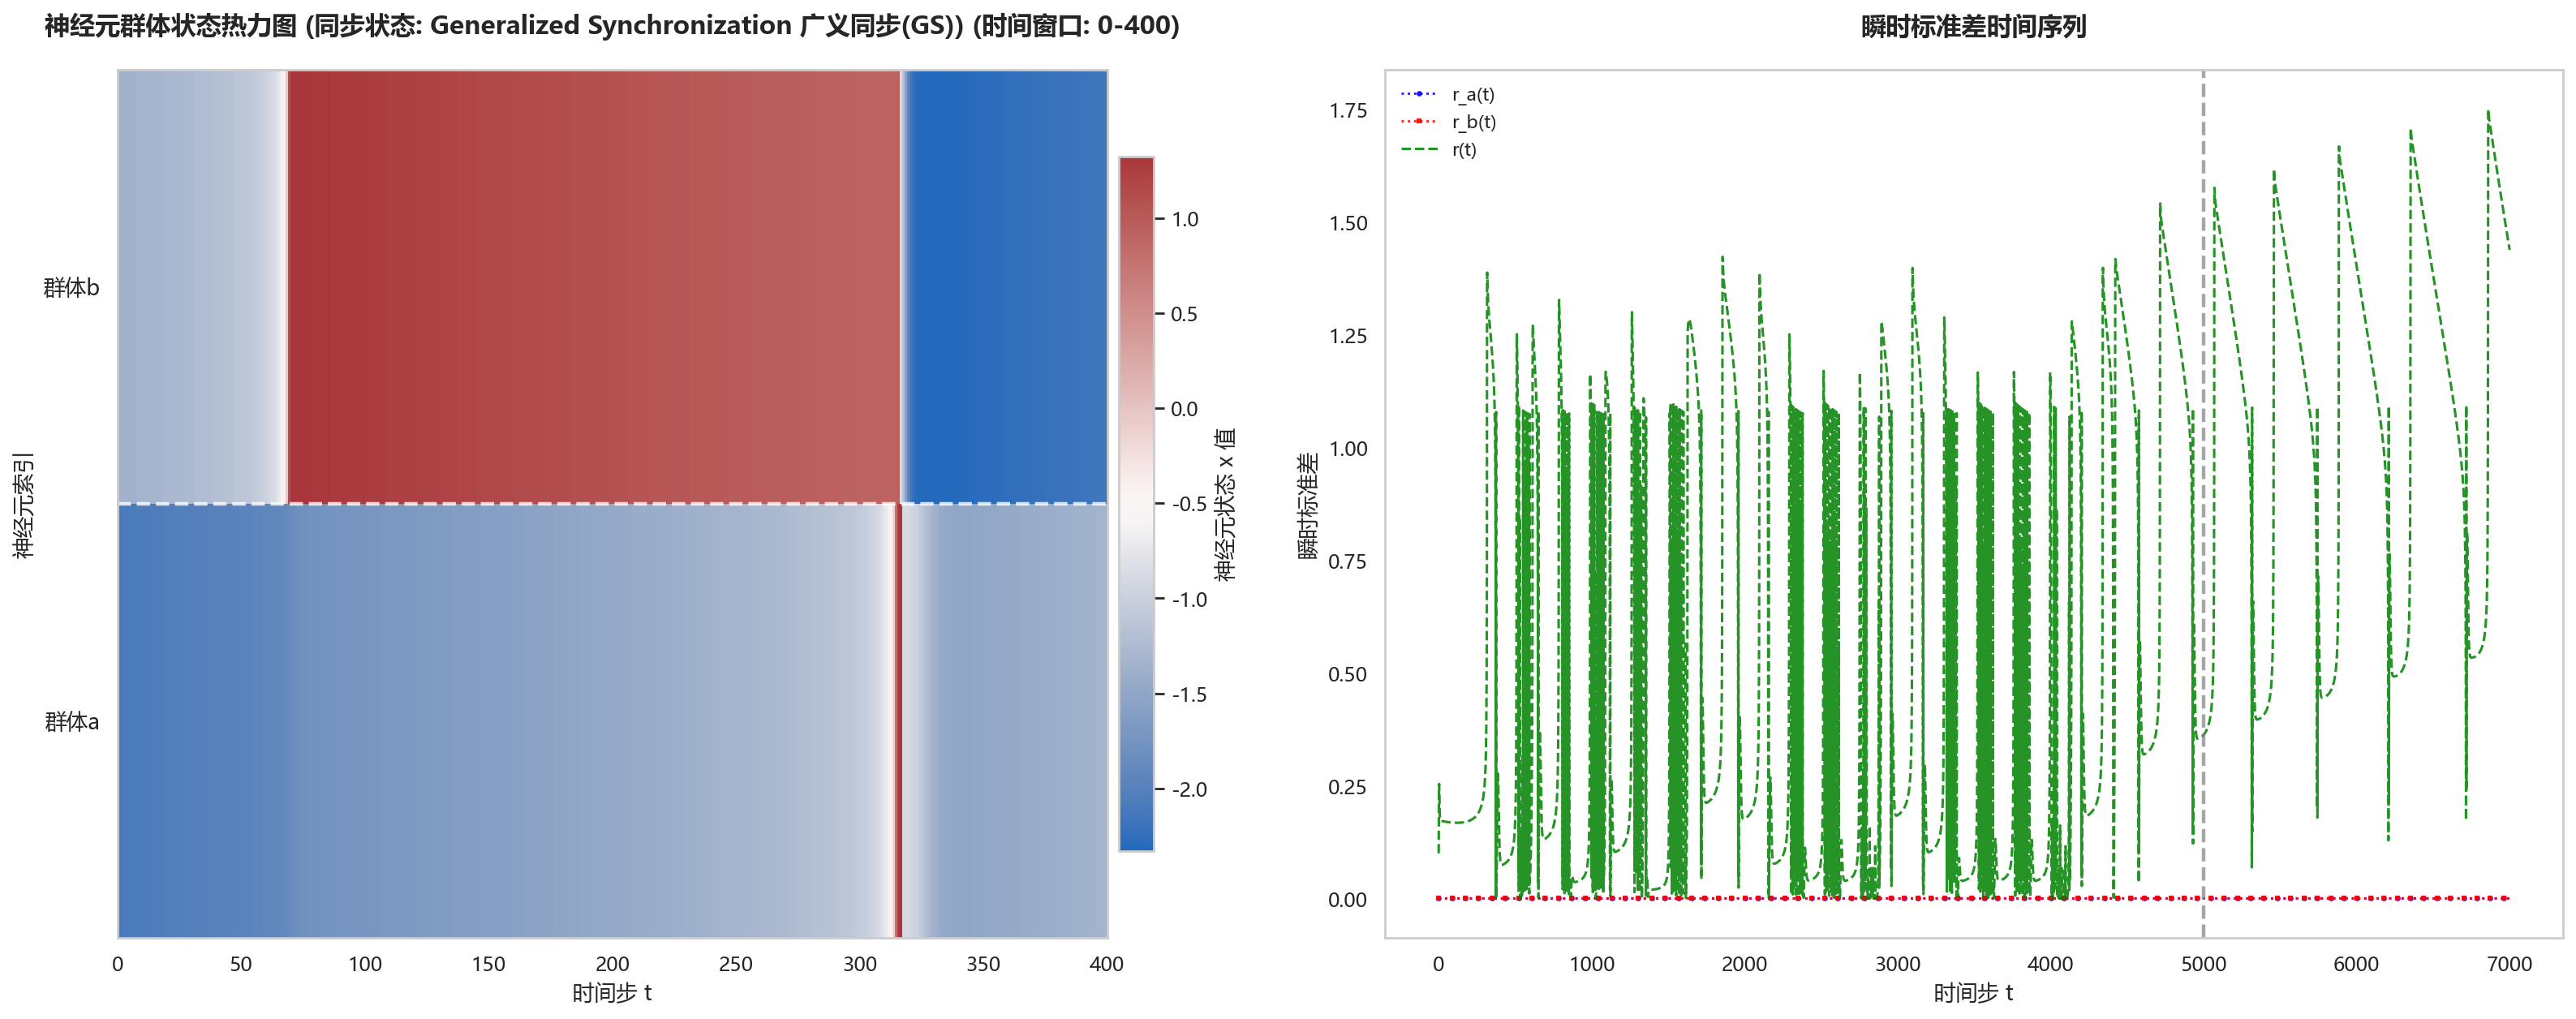

In [9]:
fig_micro, _ = plot_neuron_analysis_combo(
    data,
    time_window=(0, 400),
    cmap='vlag',
)
display(fig_micro)
plt.close(fig_micro)


## 5. 将微观数据组装为状态矩阵

这一步在做什么：

- 把两群体神经元的 `x/y` 序列展开成单个 state matrix
- 检查后续 Koopman 拟合所用的输入维度


In [11]:
state_matrix, state_names = build_state_matrix_from_population_data(data)
state_df = pd.DataFrame(state_matrix[:, :12], columns=state_names[:12])
print('state_matrix shape =', state_matrix.shape)
print('number of state channels =', len(state_names))
display(state_df.head())


state_matrix shape = (2000, 400)
number of state channels = 400


,x_a1,y_a1,x_a2,y_a2,x_a3,y_a3,x_a4,y_a4,x_a5,y_a5,x_a6,y_a6
0,-2.093093,-3.548341,-2.093093,-3.548341,-2.093093,-3.548341,-2.093093,-3.548341,-2.093093,-3.548341,-2.093093,-3.548341
1,-2.090408,-3.547023,-2.090408,-3.547023,-2.090408,-3.547023,-2.090408,-3.547023,-2.090408,-3.547023,-2.090408,-3.547023
2,-2.087723,-3.545707,-2.087723,-3.545707,-2.087723,-3.545707,-2.087723,-3.545707,-2.087723,-3.545707,-2.087723,-3.545707
3,-2.085039,-3.544395,-2.085039,-3.544395,-2.085039,-3.544395,-2.085039,-3.544395,-2.085039,-3.544395,-2.085039,-3.544395
4,-2.082354,-3.543084,-2.082354,-3.543084,-2.082354,-3.543084,-2.082354,-3.543084,-2.082354,-3.543084,-2.082354,-3.543084


## 6. 构造 observables library

这一步在做什么：

- 基于微观 state matrix 构造 `identity + quadratic` 观测库
- 查看特征数和前几个特征名


In [13]:
lifted_matrix, feature_names = build_observables(state_matrix, state_names, workflow_config.observables)
feature_preview = pd.DataFrame({
    'feature_name': feature_names[:20],
    'sample_value_t0': lifted_matrix[0, :20],
    'sample_value_t1': lifted_matrix[1, :20],
})
print('lifted_matrix shape =', lifted_matrix.shape)
print('number of features =', len(feature_names))
display(feature_preview)


lifted_matrix shape = (2000, 800)
number of features = 800


,feature_name,sample_value_t0,sample_value_t1
0,x_a1,-2.093093,-2.090408
1,y_a1,-3.548341,-3.547023
2,x_a2,-2.093093,-2.090408
3,y_a2,-3.548341,-3.547023
4,x_a3,-2.093093,-2.090408
5,y_a3,-3.548341,-3.547023
6,x_a4,-2.093093,-2.090408
7,y_a4,-3.548341,-3.547023
8,x_a5,-2.093093,-2.090408
9,y_a5,-3.548341,-3.547023


## 7. 拟合 Koopman 主链路的统计量

这一步在做什么：

- 构造 `X_t` 与 `X_{t+1}` 配对
- 计算 `C00/C01/C11`
- 得到 data-fitted step operator 和 empirical whitened Koopman


In [15]:
x_pairs = lifted_matrix[:-workflow_config.lag_steps]
y_pairs = lifted_matrix[workflow_config.lag_steps:]
koopman_stats = fit_data_koopman_operator(
    [lifted_matrix],
    lag_steps=workflow_config.lag_steps,
    ridge=workflow_config.ridge,
    eps=workflow_config.eps,
)
operator_matrix = koopman_stats['A']
whitened_matrix = koopman_stats['K_bar']
preview_n = min(10, len(feature_names))
print('x_pairs shape =', x_pairs.shape)
print('y_pairs shape =', y_pairs.shape)
display(pd.DataFrame(koopman_stats['C00'][:preview_n, :preview_n], index=feature_names[:preview_n], columns=feature_names[:preview_n]))
display(pd.DataFrame(koopman_stats['C01'][:preview_n, :preview_n], index=feature_names[:preview_n], columns=feature_names[:preview_n]))
display(pd.DataFrame(koopman_stats['C11'][:preview_n, :preview_n], index=feature_names[:preview_n], columns=feature_names[:preview_n]))


x_pairs shape = (1999, 800)
y_pairs shape = (1999, 800)


,x_a1,y_a1,x_a2,y_a2,x_a3,y_a3,x_a4,y_a4,x_a5,y_a5
x_a1,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060
y_a1,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921
x_a2,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060
y_a2,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921
x_a3,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060
y_a3,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921
x_a4,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060
y_a4,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921
x_a5,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060,2.460222,2.834060
y_a5,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921,2.834060,12.135921


,x_a1,y_a1,x_a2,y_a2,x_a3,y_a3,x_a4,y_a4,x_a5,y_a5
x_a1,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231
y_a1,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784
x_a2,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231
y_a2,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784
x_a3,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231
y_a3,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784
x_a4,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231
y_a4,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784
x_a5,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231,2.454586,2.832231
y_a5,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784,2.835325,12.135784


,x_a1,y_a1,x_a2,y_a2,x_a3,y_a3,x_a4,y_a4,x_a5,y_a5
x_a1,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502
y_a1,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648
x_a2,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502
y_a2,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648
x_a3,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502
y_a3,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648
x_a4,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502
y_a4,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648
x_a5,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502,2.459684,2.833502
y_a5,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648,2.833502,12.135648


## 8. 模型 operator 与 correct whitening

这一步在做什么：

- 额外用一个线性 model 对 lifted dynamics 做回归
- 将 model operator 用同一套 `C00/C11` 做 correct whitening
- 于是 notebook 中会同时有 3 个 K 版本


In [17]:
ridge_alpha = max(workflow_config.ridge, 1e-8)
linear_model = Ridge(alpha=ridge_alpha, fit_intercept=False)
linear_model.fit(x_pairs, y_pairs)
model_operator = linear_model.coef_.T
model_whitening = whiten_operator_matrix(
    model_operator,
    koopman_stats['C00'],
    koopman_stats['C11'],
    eps=workflow_config.eps,
)
model_whitened_matrix = model_whitening['A_bar']
print('operator_matrix shape =', operator_matrix.shape)
print('model_operator shape =', model_operator.shape)
print('whitened_matrix shape =', whitened_matrix.shape)


operator_matrix shape = (800, 800)
model_operator shape = (800, 800)
whitened_matrix shape = (800, 800)


E:\Anaconda3\envs\pykoopman310\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.60396e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## 9. 三种 K 矩阵逐一展示

这一步在做什么：

- 对比 `data-fitted step operator`
- 对比 `model operator with correct whitening`
- 对比 `empirical whitened Koopman`


,x_a1,y_a1,x_a2,y_a2,x_a3,y_a3,x_a4,y_a4
x_a1,-0.004146,-0.043716,-0.004146,-0.043716,-0.004146,-0.043716,-0.004146,-0.043716
y_a1,-0.000603,0.000568,-0.000603,0.000568,-0.000603,0.000568,-0.000603,0.000568
x_a2,0.009403,0.007784,0.009403,0.007784,0.009403,0.007784,0.009403,0.007784
y_a2,-0.000509,0.000344,-0.000509,0.000344,-0.000509,0.000344,-0.000509,0.000344
x_a3,0.008986,0.004366,0.008986,0.004366,0.008986,0.004366,0.008986,0.004366
y_a3,0.001533,0.009244,0.001533,0.009244,0.001533,0.009244,0.001533,0.009244
x_a4,0.009583,0.009904,0.009583,0.009904,0.009583,0.009904,0.009583,0.009904
y_a4,0.001132,0.010124,0.001132,0.010124,0.001132,0.010124,0.001132,0.010124


,x_a1,y_a1,x_a2,y_a2,x_a3,y_a3,x_a4,y_a4
x_a1,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055
y_a1,-0.000035,0.009982,-0.000036,0.009982,-0.000035,0.009982,-0.000035,0.009982
x_a2,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055
y_a2,-0.000035,0.009982,-0.000036,0.009982,-0.000035,0.009982,-0.000035,0.009982
x_a3,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055
y_a3,-0.000035,0.009982,-0.000036,0.009982,-0.000035,0.009982,-0.000035,0.009982
x_a4,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055
y_a4,-0.000035,0.009982,-0.000036,0.009982,-0.000035,0.009982,-0.000035,0.009982


,x_a1,y_a1,x_a2,y_a2,x_a3,y_a3,x_a4,y_a4
x_a1,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055
y_a1,-0.000035,0.009983,-0.000036,0.009983,-0.000035,0.009983,-0.000035,0.009983
x_a2,0.009830,-0.000054,0.009830,-0.000054,0.009830,-0.000054,0.009830,-0.000054
y_a2,-0.000035,0.009982,-0.000036,0.009983,-0.000035,0.009983,-0.000035,0.009983
x_a3,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055,0.009830,-0.000055
y_a3,-0.000035,0.009982,-0.000036,0.009982,-0.000035,0.009982,-0.000035,0.009982
x_a4,0.009830,-0.000055,0.009830,-0.000054,0.009830,-0.000054,0.009830,-0.000054
y_a4,-0.000035,0.009982,-0.000036,0.009982,-0.000035,0.009982,-0.000035,0.009982


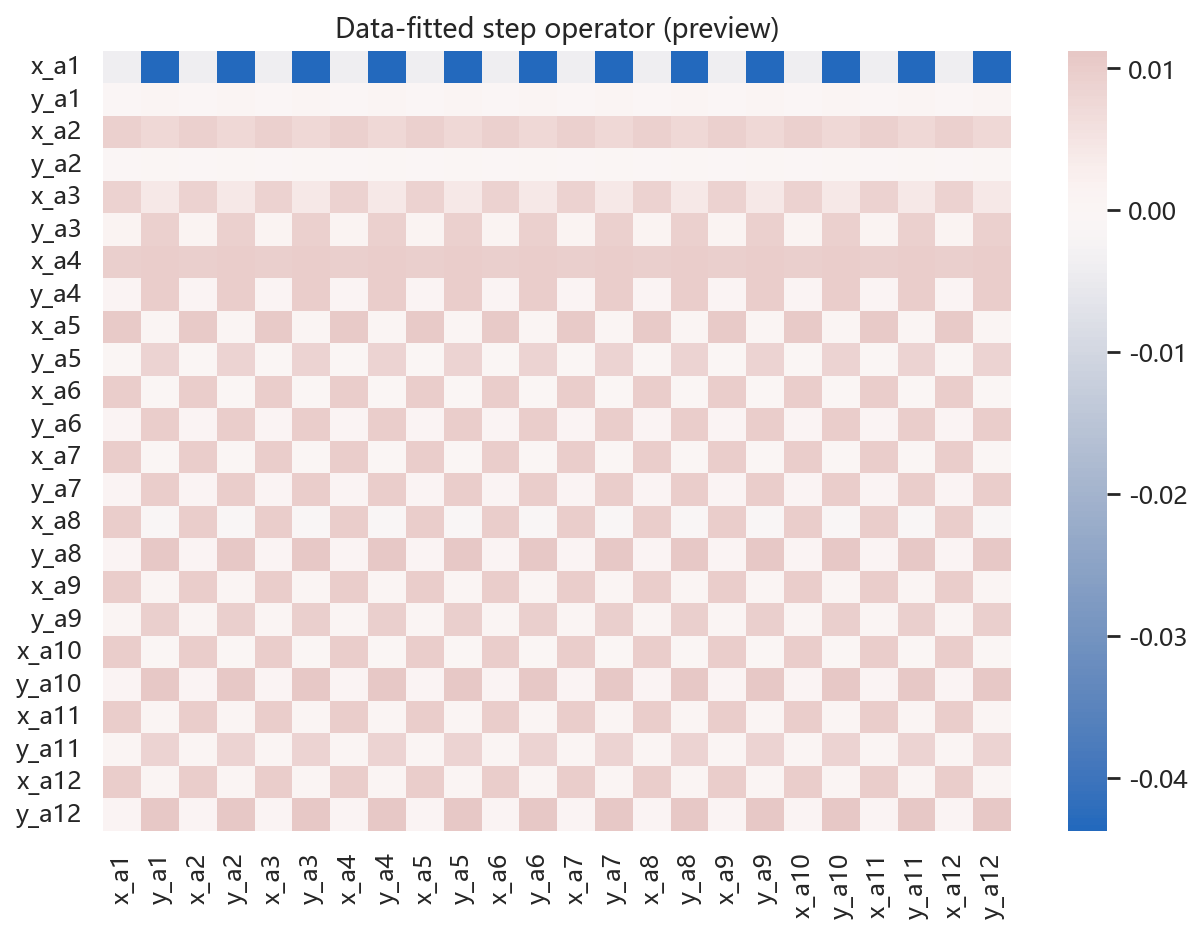

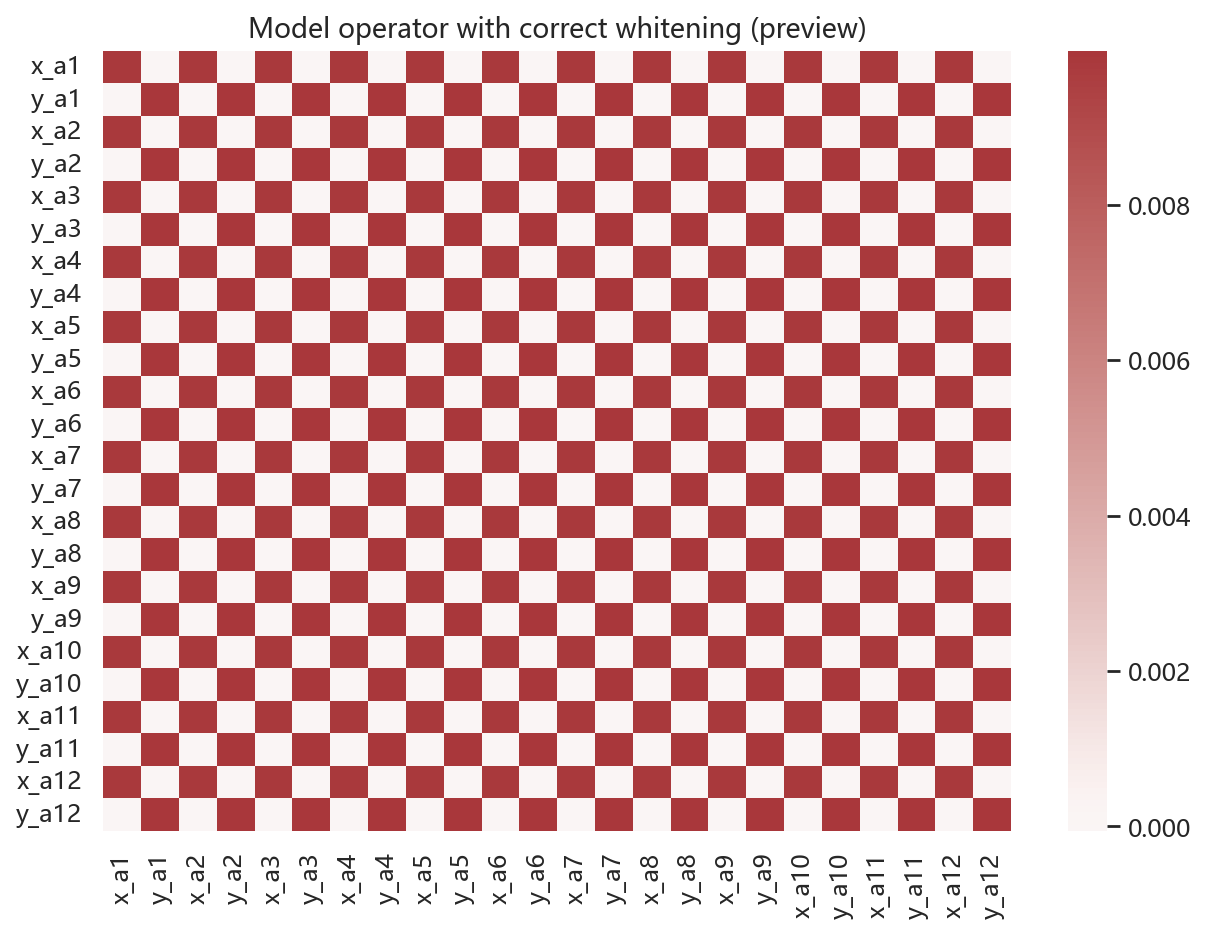

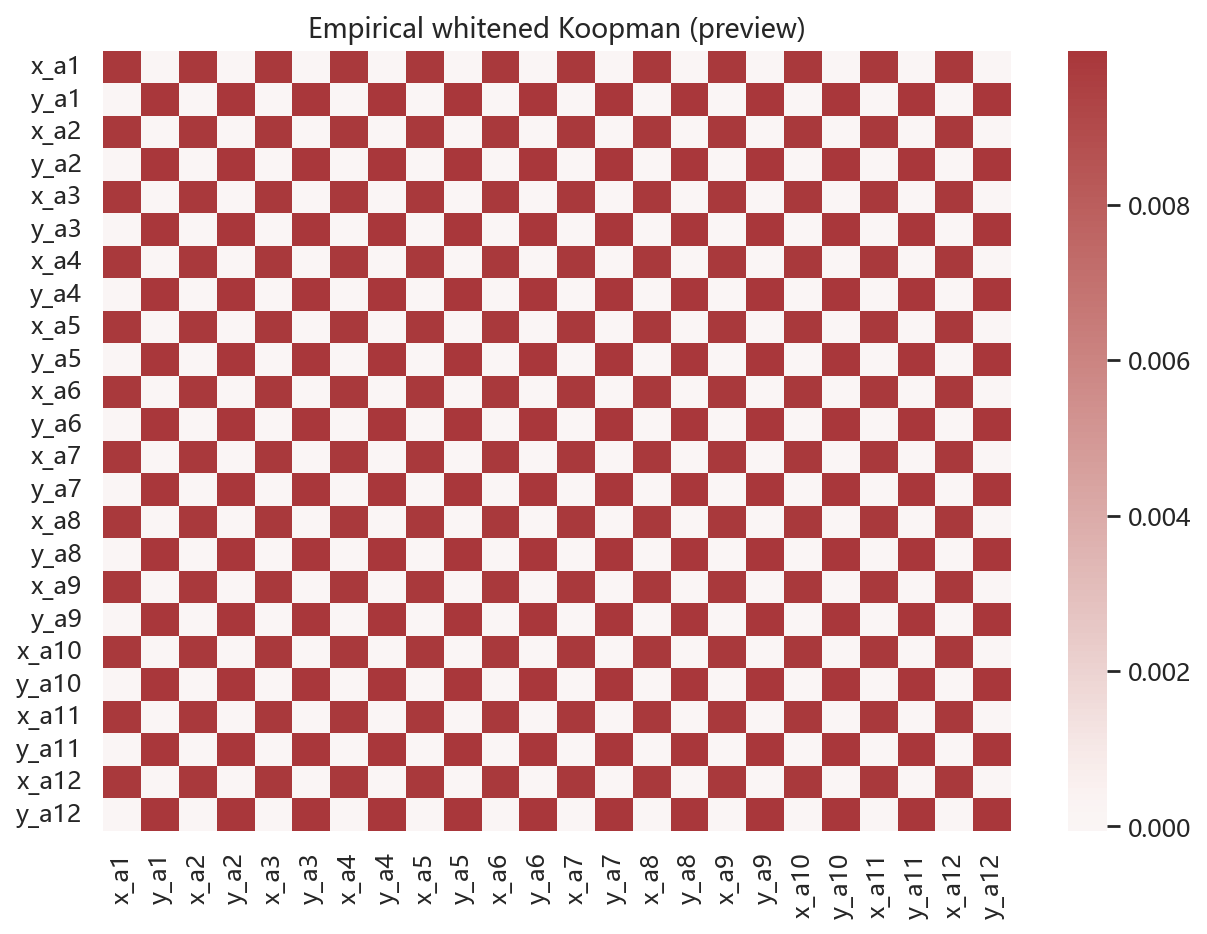

In [19]:
preview_n = min(24, len(feature_names))
fig_k1, _ = plot_matrix_heatmap(
    operator_matrix[:preview_n, :preview_n],
    feature_names[:preview_n],
    'Data-fitted step operator (preview)',
    figsize=(8, 6),
)
fig_k2, _ = plot_matrix_heatmap(
    model_whitened_matrix[:preview_n, :preview_n],
    feature_names[:preview_n],
    'Model operator with correct whitening (preview)',
    figsize=(8, 6),
)
fig_k3, _ = plot_matrix_heatmap(
    whitened_matrix[:preview_n, :preview_n],
    feature_names[:preview_n],
    'Empirical whitened Koopman (preview)',
    figsize=(8, 6),
)
display(pd.DataFrame(operator_matrix[:8, :8], index=feature_names[:8], columns=feature_names[:8]))
display(pd.DataFrame(model_whitened_matrix[:8, :8], index=feature_names[:8], columns=feature_names[:8]))
display(pd.DataFrame(whitened_matrix[:8, :8], index=feature_names[:8], columns=feature_names[:8]))
display(fig_k1)
display(fig_k2)
display(fig_k3)
plt.close(fig_k1)
plt.close(fig_k2)
plt.close(fig_k3)


## 10. 奇异值谱对比

这一步在做什么：

- 分别对 3 种 K 计算奇异值
- 像 0313 一样放在同一张图里进行比较


,index,data_fitted_step,model_correct_whitening,empirical_whitened_koopman
0,1,4.383243e+00,1.000000e+00,1.000000e+00
1,2,1.229475e+00,1.000000e+00,1.000000e+00
2,3,1.128435e+00,9.999999e-01,9.999999e-01
3,4,1.013199e+00,9.999842e-01,9.999842e-01
4,5,9.992340e-01,9.991419e-01,9.991419e-01
5,6,9.754561e-01,9.981331e-01,9.981331e-01
6,7,8.918837e-01,9.734071e-01,9.734071e-01
7,8,2.268508e-01,9.621439e-01,9.621439e-01
8,9,3.457456e-14,1.095537e-09,1.152551e-09
9,10,3.157968e-14,9.916135e-10,1.126584e-09


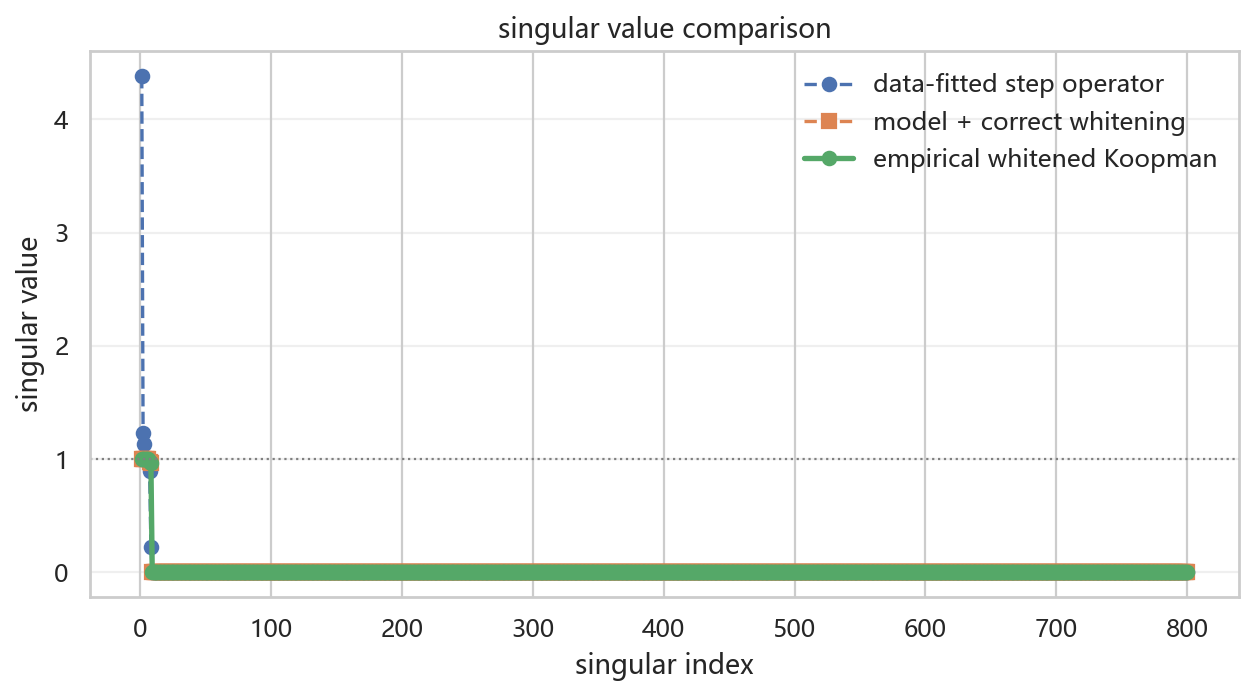

In [21]:
raw_operator_singular_values = np.linalg.svd(operator_matrix, compute_uv=False)
model_whitened_singular_values = np.linalg.svd(model_whitened_matrix, compute_uv=False)
singular_values = np.linalg.svd(whitened_matrix, compute_uv=False)
sv_fig, _ = plot_singular_value_comparison(
    raw_operator_singular_values,
    model_whitened_singular_values,
    singular_values,
)
sv_df = pd.DataFrame({
    'index': np.arange(1, min(20, len(singular_values)) + 1),
    'data_fitted_step': raw_operator_singular_values[:20],
    'model_correct_whitening': model_whitened_singular_values[:20],
    'empirical_whitened_koopman': singular_values[:20],
})
display(sv_df)
display(sv_fig)
plt.close(sv_fig)


## 11. rank 截断、CE 与 EC

这一步在做什么：

- 对 whitened Koopman 做 SVD
- 按设定 rank 进行截断
- 计算 EC 指标与 CE 指标


In [23]:
u, s, vt = np.linalg.svd(whitened_matrix, full_matrices=False)
rank = workflow_config.rank
u_r = u[:, :rank]
s_r = s[:rank]
vt_r = vt[:rank, :]

coarse_matrix = koopman_stats['C00_inv_sqrt'] @ u_r
macro_names = [f'z{i + 1}' for i in range(rank)]
macro_series = lifted_matrix @ coarse_matrix
macro_operator = np.linalg.pinv(macro_series[:-1]) @ macro_series[1:]

ce_channel_scores = channel_scores_from_singular_values(s, alpha=workflow_config.alpha, rank=rank)
ce_score = float(np.sum(ce_channel_scores))
ce_total_from_kbar = float(koopman_ce_total_score_from_kbar(whitened_matrix, alpha=workflow_config.alpha, eps=workflow_config.eps))
ec_increments = get_positive_contributions(s[:rank].tolist())
ec_score = float(compute_entropy(ec_increments))
residual_covariance = compute_residual_covariance(x_pairs, y_pairs, model_operator, eps=workflow_config.eps)
closed_form_ce = None
if workflow_config.include_closed_form_ce:
    closed_form_ce = float(
        liu2025_log_gamma_gis(
            model_operator,
            residual_covariance,
            alpha=workflow_config.alpha,
            eps=workflow_config.eps,
        )
    )
metrics_df = pd.DataFrame([
    {
        'rank': rank,
        'EC': ec_score,
        'CE_rank_sum': ce_score,
        'CE_total_from_kbar': ce_total_from_kbar,
        'closed_form_ce': closed_form_ce,
    }
])
display(metrics_df)
print('top singular values =', s[:10])
print('EC increments =', ec_increments)
print('CE channel scores =', ce_channel_scores)


top singular values = [1.     1.     1.     1.     0.9991 0.9981 0.9734 0.9621 0.     0.    ]
EC increments = [np.float64(3.2021283978383056e-09)]
CE channel scores = [9.2103 9.2103]


,rank,EC,CE_rank_sum,CE_total_from_kbar,closed_form_ce
0,2,0.0,18.420681,-1658.773577,-1130.432648


## 12. 左奇异向量与粗粒化表达

这一步在做什么：

- 查看戴 rank 截断的左奇异向量
- 生成对应的 coarse-graining 表达式


z1 = 0
z2 = 0


,z1,z2
x_a1,0.000026,-0.006236
y_a1,-0.013817,-0.006780
x_a2,0.000026,-0.006236
y_a2,-0.013817,-0.006780
x_a3,0.000026,-0.006236
y_a3,-0.013817,-0.006780
x_a4,0.000026,-0.006236
y_a4,-0.013817,-0.006780
x_a5,0.000026,-0.006236
y_a5,-0.013817,-0.006780


,z1,z2
x_a1,-0.000426,-0.000221
y_a1,0.020017,0.020364
x_a2,0.006477,0.001865
y_a2,0.014031,0.016566
x_a3,-0.000709,-0.001050
y_a3,0.012291,0.013342
x_a4,0.000737,0.000763
y_a4,0.011862,0.013538
x_a5,-0.000302,-0.000255
y_a5,0.011822,0.012761


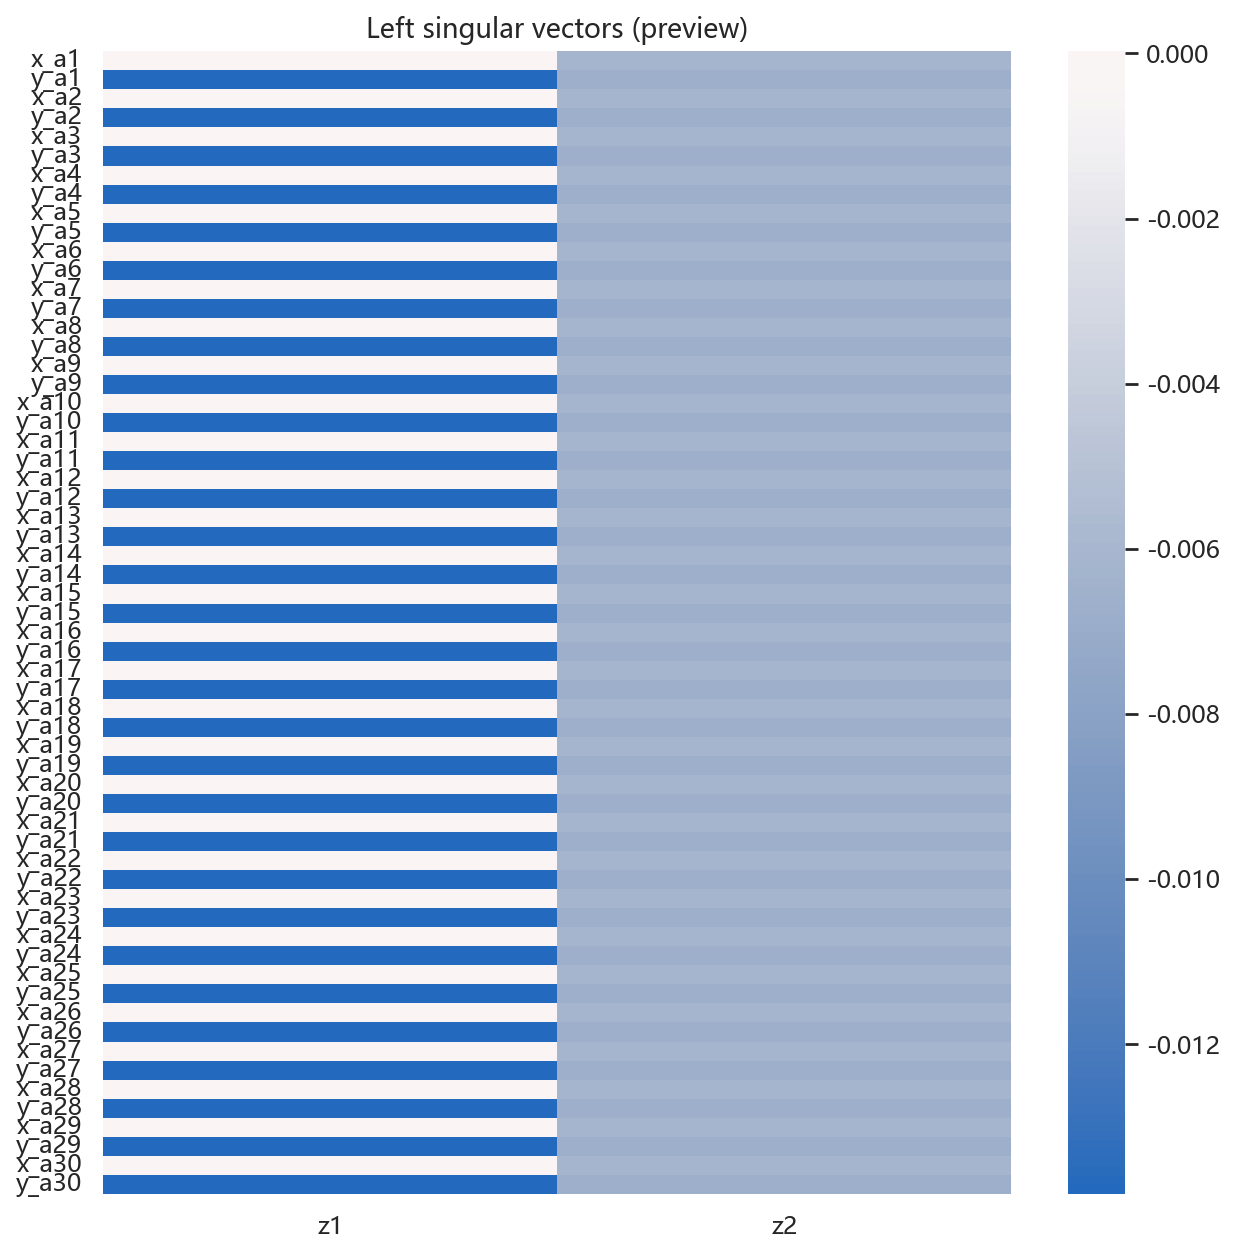

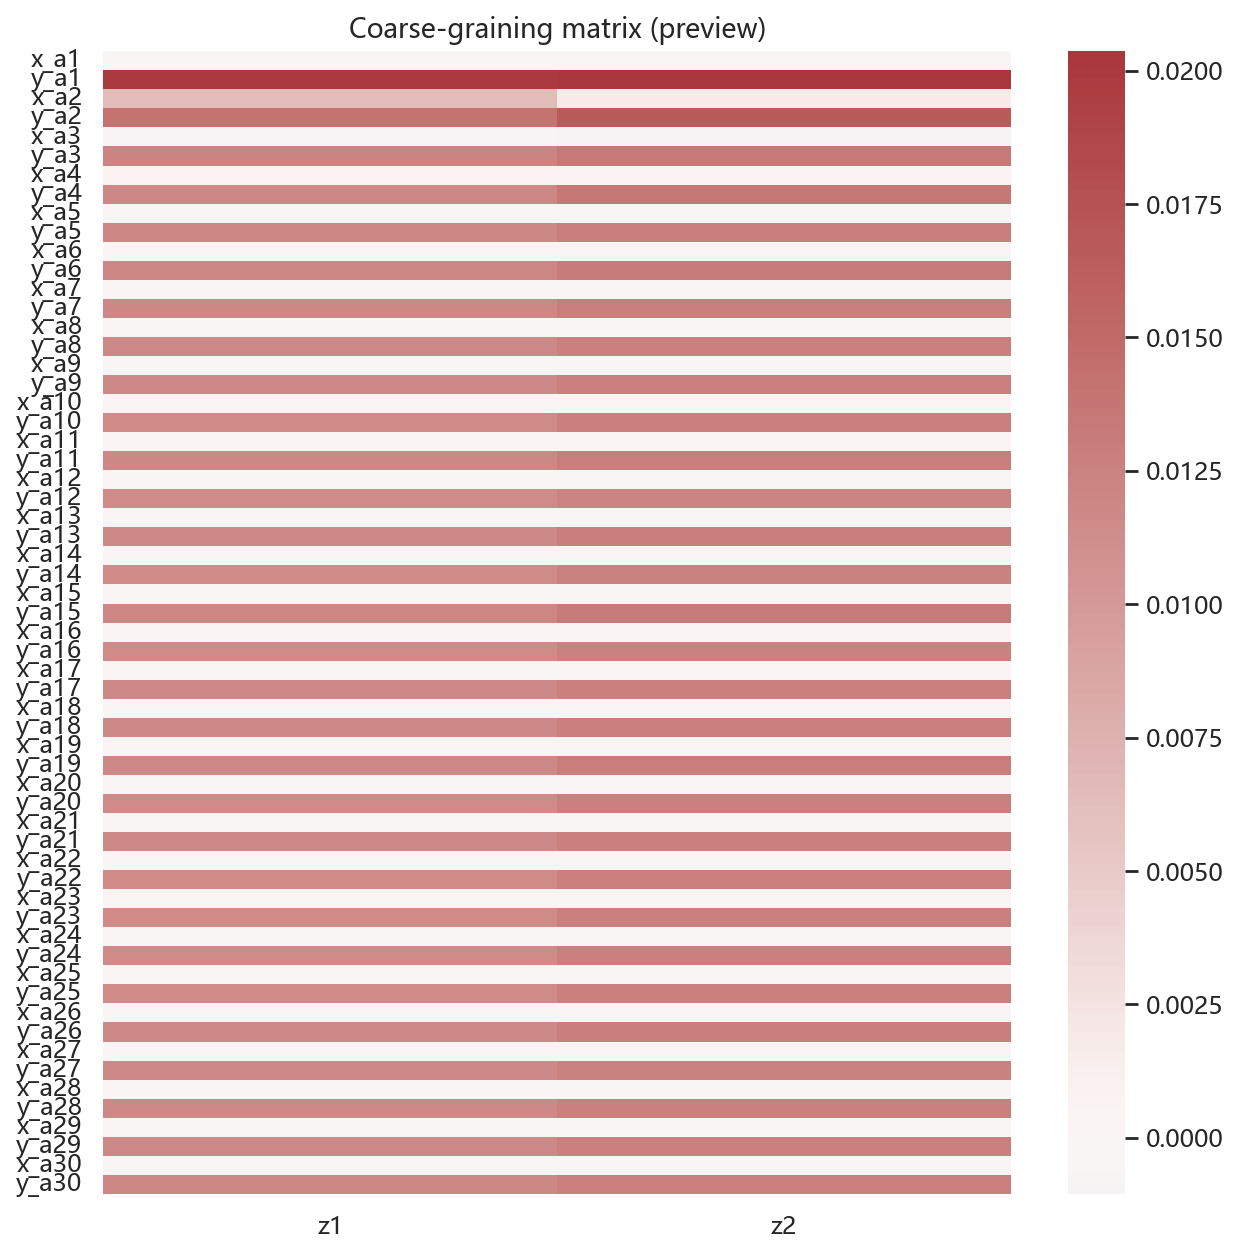

In [25]:
row_preview = min(60, len(feature_names))
left_sv_fig, _ = plot_rectangular_heatmap(
    u_r[:row_preview, :],
    feature_names[:row_preview],
    macro_names,
    'Left singular vectors (preview)',
    figsize=(8, 8),
)
coarse_fig, _ = plot_rectangular_heatmap(
    coarse_matrix[:row_preview, :],
    feature_names[:row_preview],
    macro_names,
    'Coarse-graining matrix (preview)',
    figsize=(8, 8),
)
coarse_equations = format_equations(coarse_matrix, feature_names, macro_names, threshold=0.08)
display(pd.DataFrame(u_r[:12, :], index=feature_names[:12], columns=macro_names))
display(pd.DataFrame(coarse_matrix[:12, :], index=feature_names[:12], columns=macro_names))
for equation in coarse_equations[:rank]:
    print(equation)
display(left_sv_fig)
display(coarse_fig)
plt.close(left_sv_fig)
plt.close(coarse_fig)


## 13. 宏观时间序列与对照图

这一步在做什么：

- 输出 macro time series
- 新增“原始微观变量 vs 宏观变量”对照图
- 微观变量只挑几条具代表性的通道


,z1,z2
0,1.103634,0.107265
1,1.100054,0.108678
2,1.096482,0.110092
3,1.092916,0.111509
4,1.089358,0.112928
5,1.085806,0.114350
6,1.082261,0.115775
7,1.078723,0.117203
8,1.075191,0.118633
9,1.071666,0.120066


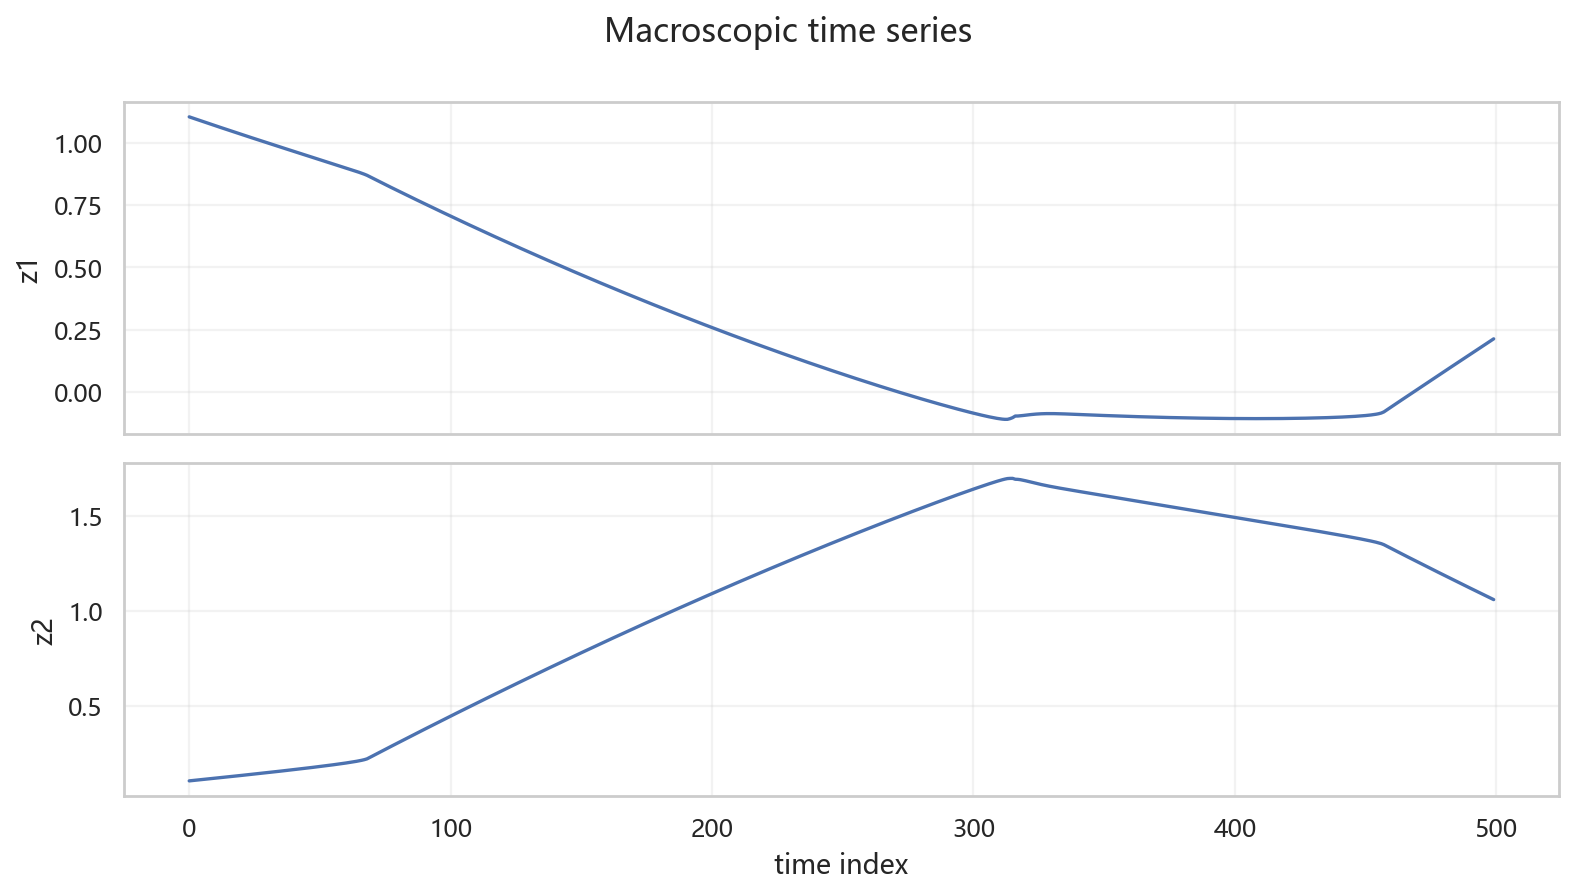

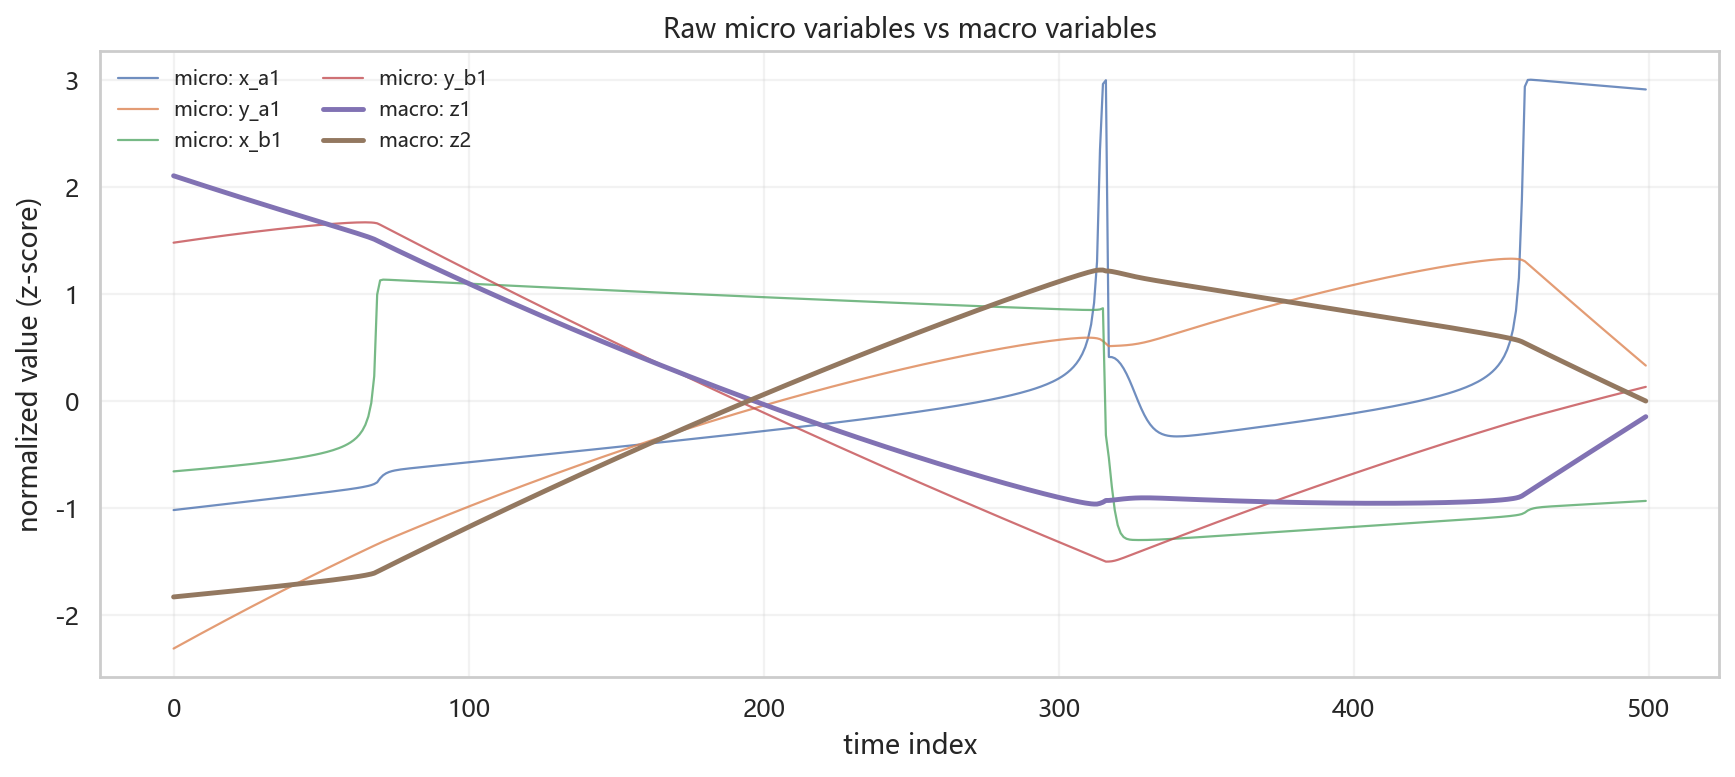

In [27]:
macro_fig, _ = plot_macro_series(macro_series, macro_names, max_points=500)
picked_micro_indices = [0, 1, 2 * simulation_config.n_a, 2 * simulation_config.n_a + 1]
comparison_fig, _ = plot_micro_macro_comparison(
    state_matrix,
    state_names,
    macro_series,
    macro_names,
    picked_indices=picked_micro_indices,
    max_points=500,
)
display(pd.DataFrame(macro_series[:10, :], columns=macro_names))
display(macro_fig)
display(comparison_fig)
plt.close(macro_fig)
plt.close(comparison_fig)


## 14. 宏观动力学方程

这一步在做什么：

- 在 rank 截断后的 macro coordinates 上再拟合一个线性步进模型
- 输出宏观动力学矩阵和方程


In [29]:
macro_equations = format_equations(
    macro_operator,
    macro_names,
    [f'{name}_next' for name in macro_names],
    threshold=1e-4,
)
display(pd.DataFrame(macro_operator, index=macro_names, columns=macro_names))
for equation in macro_equations:
    print(equation)


z1_next = 0.9998 * z1
z2_next = 0.0003 * z1 + 1.0002 * z2


,z1,z2
z1,0.999774,0.000252
z2,-0.000024,1.000172


## 15. 保存结果

这一步在做什么：

- 将 csv/json/png 全部覆盖保存到 `exp/map/results/`
- 保留 notebook 内显示的同时，也保留稳定的落盘结果


In [31]:
summary_metrics = pd.DataFrame([
    {
        'rank': rank,
        'n_states': state_matrix.shape[1],
        'n_features': lifted_matrix.shape[1],
        'EC': ec_score,
        'CE_rank_sum': ce_score,
        'CE_total_from_kbar': ce_total_from_kbar,
        'closed_form_ce': closed_form_ce,
    }
])
workflow = {
    'config': workflow_config,
    'simulation': data,
    'state_matrix': state_matrix,
    'state_names': state_names,
    'lifted_matrix': lifted_matrix,
    'feature_names': feature_names,
    'koopman': koopman_stats,
    'operator_matrix': operator_matrix,
    'model_whitened_matrix': model_whitened_matrix,
    'whitened_matrix': whitened_matrix,
    'raw_operator_singular_values': raw_operator_singular_values,
    'model_whitened_singular_values': model_whitened_singular_values,
    'singular_values': s,
    'singular_vectors_left': u,
    'rank': rank,
    'macro_names': macro_names,
    'coarse_matrix': coarse_matrix,
    'macro_series': macro_series,
    'macro_operator': macro_operator,
    'summary': summary_metrics,
    'ec_increments': ec_increments,
    'ce_channel_scores': ce_channel_scores,
    'ec_score': ec_score,
    'ce_score': ce_score,
    'ce_total_from_kbar': ce_total_from_kbar,
    'closed_form_ce': closed_form_ce,
    'coarse_equations': coarse_equations,
    'macro_equations': macro_equations,
}
artifacts = save_workflow_results(workflow, results_dir)
display(summary_metrics)
print('saved files =', len(artifacts))
for key in sorted(list(artifacts))[:12]:
    print(key, '->', artifacts[key])


saved files = 29
C00 -> E:\code\pykoop\exp\map\results\C00.csv
C00.png -> E:\code\pykoop\exp\map\results\C00.png
C01 -> E:\code\pykoop\exp\map\results\C01.csv
C01.png -> E:\code\pykoop\exp\map\results\C01.png
C11 -> E:\code\pykoop\exp\map\results\C11.csv
C11.png -> E:\code\pykoop\exp\map\results\C11.png
K_matrix -> E:\code\pykoop\exp\map\results\K_matrix.csv
K_matrix.png -> E:\code\pykoop\exp\map\results\K_matrix.png
Kbar_matrix -> E:\code\pykoop\exp\map\results\Kbar_matrix.csv
Kbar_matrix.png -> E:\code\pykoop\exp\map\results\Kbar_matrix.png
coarse_graining_matrix -> E:\code\pykoop\exp\map\results\coarse_graining_matrix.csv
coarse_graining_matrix.png -> E:\code\pykoop\exp\map\results\coarse_graining_matrix.png


,rank,n_states,n_features,EC,CE_rank_sum,CE_total_from_kbar,closed_form_ce
0,2,400,800,0.0,18.420681,-1658.773577,-1130.432648
